<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/smearing_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install uproot
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 55.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot
import os

import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]


df = tree.arrays(branches, library="pd")
df.head()

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm
0,slurm_36283167_1,43,0,3,22.533781,45.725643,-6.039716,187.380234,187.380234,0.0,3.079860,6.565360,-6.969770
1,slurm_36283167_1,43,1,3,-19.154974,-41.295967,42.954437,471.598907,471.598907,0.0,3.079860,6.565360,-6.969770
2,slurm_36283167_1,43,2,3,10.009033,22.802109,-44.240387,363.018677,363.018677,0.0,3.079860,6.565360,-6.969770
3,slurm_36283167_1,56,0,3,15.187184,14.526692,46.622974,492.708618,492.708618,0.0,-0.369778,0.324251,-4.727468
4,slurm_36283167_1,56,1,3,1.183054,-10.753192,-51.622868,304.623718,304.623718,0.0,-0.369778,0.324251,-4.727468


In [4]:
N_EVENTS = 15000

events = df[["RunID", "EventID"]].drop_duplicates()
events_subset = events.head(N_EVENTS)

df_subset = df.merge(events_subset, on=["RunID", "EventID"], how="inner")

print("Events selected:", len(events_subset))
print("Rows selected:  ", len(df_subset))
print("Events in subset:", df_subset.groupby(["RunID", "EventID"]).ngroups)

Events selected: 15000
Rows selected:   45000
Events in subset: 15000


In [25]:
REFERENCE_ENERGY_KEV = 511.0  # keV
FWHM_TO_SIGMA = 2.355

def smear_energy(energy_keV, fwhm_percent, rng):
    if energy_keV <= 0:
        return 0.0

    fwhm_511 = (fwhm_percent / 100.0) * REFERENCE_ENERGY_KEV
    fwhm = fwhm_511 * np.sqrt(energy_keV / REFERENCE_ENERGY_KEV)
    sigma = fwhm / FWHM_TO_SIGMA

    smeared = rng.normal(energy_keV, sigma)
    while smeared < 0:
        smeared = rng.normal(energy_keV, sigma)

    return float(smeared)


if "EnergyDeposit_keV_true" not in df_subset.columns:
    df_subset["EnergyDeposit_keV_true"] = df_subset["EnergyDeposit_keV"].copy()

print(df_subset["EnergyDeposit_keV_true"].describe())

count    45000.000000
mean       340.665924
std        115.688095
min         14.587440
25%        258.388206
50%        356.922058
75%        438.375610
max        510.995605
Name: EnergyDeposit_keV_true, dtype: float64


In [10]:
#use for baseline smeared energy
def build_event_arrays_2d(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    n_angle_calls = 0
    n_out_of_range = 0
    n_events_with_out_of_range = 0

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):

        event = event.sort_values(
            ["EnergyDeposit_keV", "GammaIndex"],
            ascending=[False, True]
        ).reset_index(drop=True)

        if len(event) < 3:
            continue

        event = event.iloc[:3]

        hit1 = event[["X_mm", "Y_mm", "Z_mm"]].iloc[0].values.astype(float)
        hit2 = event[["X_mm", "Y_mm", "Z_mm"]].iloc[1].values.astype(float)
        hit3 = event[["X_mm", "Y_mm", "Z_mm"]].iloc[2].values.astype(float)

        v1 = hit2 - hit1
        v2 = hit3 - hit1
        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length
        basis_u = v1 / (np.linalg.norm(v1) + 1e-8)
        basis_v = np.cross(normal, basis_u)
        basis_v = basis_v / (np.linalg.norm(basis_v) + 1e-8)

        plane_data = np.concatenate([hit1, normal, basis_u, basis_v])
        plane_list.append(plane_data)

        energy1 = float(event.iloc[0]["EnergyDeposit_keV"])
        energy2 = float(event.iloc[1]["EnergyDeposit_keV"])
        energy3 = float(event.iloc[2]["EnergyDeposit_keV"])

        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        def gamma_opening_angle(e_i, e_j, e_k):
            cos_theta = (-e_i**2 - e_j**2 + e_k**2) / (2 * e_i * e_j + 1e-8)
            out_of_range = (cos_theta < -1.0) or (cos_theta > 1.0)
            return np.arccos(np.clip(cos_theta, -1.0, 1.0)), out_of_range

        angle1, oor1 = gamma_opening_angle(energy1, energy2, energy3)
        angle2, oor2 = gamma_opening_angle(energy2, energy3, energy1)
        angle3, oor3 = gamma_opening_angle(energy3, energy1, energy2)

        n_angle_calls += 3
        n_out_of_range += sum([oor1, oor2, oor3])
        if oor1 or oor2 or oor3:
            n_events_with_out_of_range += 1

        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])
        features_list.append(features)

        target = event[
            ["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]
        ].iloc[0].values.astype(float)
        targets_list.append(target)

    n_events_total = len(targets_list)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )

In [11]:
X_plane2d, y_plane2d, plane_data_plane2d = build_event_arrays_2d(
    df_subset
)

print("X_plane2d shape:", X_plane2d.shape)
print("y_plane2d shape:", y_plane2d.shape)
print("plane_data_plane2d shape:", plane_data_plane2d.shape)

X_plane2d shape: (15000, 18)
y_plane2d shape: (15000, 3)
plane_data_plane2d shape: (15000, 12)


In [12]:
X_train_plane2d, X_temp_plane2d, \
y_train_plane2d, y_temp_plane2d, \
plane_train_plane2d, plane_temp_plane2d = train_test_split(
    X_plane2d,
    y_plane2d,
    plane_data_plane2d,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane2d, X_test_plane2d, \
y_val_plane2d, y_test_plane2d, \
plane_val_plane2d, plane_test_plane2d = train_test_split(
    X_temp_plane2d,
    y_temp_plane2d,
    plane_temp_plane2d,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane2d.shape)
print("Validation:", X_val_plane2d.shape)
print("Test:", X_test_plane2d.shape)

Training: (12000, 18)
Validation: (2010, 18)
Test: (990, 18)


In [13]:
input_scaler_plane2d = StandardScaler()

X_train_scaled_plane2d = input_scaler_plane2d.fit_transform(
    X_train_plane2d
)

X_val_scaled_plane2d = input_scaler_plane2d.transform(
    X_val_plane2d
)

X_test_scaled_plane2d = input_scaler_plane2d.transform(
    X_test_plane2d
)

In [20]:
def xyz_to_uv_plane2d(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])


y_train_uv_plane2d = xyz_to_uv_plane2d(
    y_train_plane2d,
    plane_train_plane2d
)

y_val_uv_plane2d = xyz_to_uv_plane2d(
    y_val_plane2d,
    plane_val_plane2d
)

y_test_uv_plane2d = xyz_to_uv_plane2d(
    y_test_plane2d,
    plane_test_plane2d
)

print("Training UV:", y_train_uv_plane2d.shape)
print("Validation UV:", y_val_uv_plane2d.shape)
print("Test UV:", y_test_uv_plane2d.shape)

Training UV: (12000, 2)
Validation UV: (2010, 2)
Test UV: (990, 2)


In [21]:

class Plane2DMLP(tf.keras.Model):

    def __init__(self, hidden_units=100):
        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense3 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu" #extra dense layer
        )

        self.output_layer = tf.keras.layers.Dense(2)

    def call(self, x, training=False):

        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)

        return self.output_layer(x)

In [41]:
def uv_to_xyz_plane2d(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

energy_smearing_levels = [0, 5, 10, 12, 20, 30]  # % FWHM at 511 keV — 12 included as your existing reference point

energy_results = []

for pct in energy_smearing_levels:
    rng = np.random.default_rng(RANDOM_STATE)

    df_smeared = df_subset.copy()
    if pct == 0:
        df_smeared["EnergyDeposit_keV"] = df_smeared["EnergyDeposit_keV_true"]
    else:
        df_smeared["EnergyDeposit_keV"] = df_smeared["EnergyDeposit_keV_true"].apply(
            lambda e: smear_energy(e, pct, rng)
        )

    X, y, plane_data = build_event_arrays_2d(df_smeared)

    X_train, X_temp, y_train, y_temp, plane_train, plane_temp = train_test_split(
        X, y, plane_data, test_size=0.20, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test, plane_val, plane_test = train_test_split(
        X_temp, y_temp, plane_temp, test_size=0.33, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    y_train_uv = xyz_to_uv_plane2d(y_train, plane_train)
    y_val_uv = xyz_to_uv_plane2d(y_val, plane_val)

    model = Plane2DMLP(hidden_units=100)  # 3-layer version
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mae", metrics=["mae"])
    model.fit(X_train_scaled, y_train_uv, validation_data=(X_val_scaled, y_val_uv),
              epochs=200, batch_size=32, verbose=0)

    uv_pred = model.predict(X_test_scaled, verbose=0)
    xyz_pred = uv_to_xyz_plane2d(uv_pred, plane_test)

    mean_error = np.mean(np.linalg.norm(xyz_pred - y_test, axis=1))
    median_error = np.median(np.linalg.norm(xyz_pred - y_test, axis=1))

    x_mae = mean_absolute_error(y_test[:, 0], xyz_pred[:, 0])
    y_mae = mean_absolute_error(y_test[:, 1], xyz_pred[:, 1])
    z_mae = mean_absolute_error(y_test[:, 2], xyz_pred[:, 2])

    x_r2 = r2_score(y_test[:, 0], xyz_pred[:, 0])
    y_r2 = r2_score(y_test[:, 1], xyz_pred[:, 1])
    z_r2 = r2_score(y_test[:, 2], xyz_pred[:, 2])

    print(f"{pct}% smearing -> mean 3D error: {mean_error:.3f} mm")
    energy_results.append({"smearing_pct": pct, "mean_3d_error": mean_error, "median_3d_error": median_error,
                           "x_mae": x_mae, "y_mae": y_mae, "z_mae": z_mae,
                           "x_r2": x_r2, "y_r2": y_r2, "z_r2": z_r2})


0% smearing -> mean 3D error: 0.480 mm
5% smearing -> mean 3D error: 1.776 mm
10% smearing -> mean 3D error: 2.053 mm
12% smearing -> mean 3D error: 2.122 mm
20% smearing -> mean 3D error: 2.342 mm
30% smearing -> mean 3D error: 2.684 mm


In [42]:
energy_df = pd.DataFrame(energy_results)
energy_df

,smearing_pct,mean_3d_error,median_3d_error,x_mae,y_mae,z_mae,x_r2,y_r2,z_r2
0,0,0.479690,0.407996,0.248658,0.240516,0.233331,0.967377,0.979400,0.969344
1,5,1.775838,1.516845,0.897673,0.887572,0.887500,0.630867,0.750546,0.578130
2,10,2.052736,1.834685,1.036235,1.049929,1.010215,0.525124,0.670985,0.470964
3,12,2.122069,1.948299,1.063679,1.082644,1.048864,0.500407,0.670079,0.458384
4,20,2.342174,2.155793,1.148395,1.235881,1.145319,0.449006,0.575606,0.355970
5,30,2.683781,2.450211,1.317061,1.409787,1.313868,0.297272,0.451308,0.138831


In [44]:
uv_pred_plane2d = model.predict(X_test_scaled_plane2d)
xyz_pred_plane2d = uv_to_xyz_plane2d(uv_pred_plane2d, plane_test_plane2d)

print("uv_pred_plane2d shape:", uv_pred_plane2d.shape)
print("xyz_pred_plane2d shape:", xyz_pred_plane2d.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
uv_pred_plane2d shape: (990, 2)
xyz_pred_plane2d shape: (990, 3)


In [46]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Specific smearing percentage
pct = 2.5

print(f"Evaluating for {pct}% smearing...")

rng = np.random.default_rng(RANDOM_STATE)

df_smeared_2_5 = df_subset.copy()
if pct == 0:
    df_smeared_2_5["EnergyDeposit_keV"] = df_smeared_2_5["EnergyDeposit_keV_true"]
else:
    df_smeared_2_5["EnergyDeposit_keV"] = df_smeared_2_5["EnergyDeposit_keV_true"].apply(
        lambda e: smear_energy(e, pct, rng)
    )

X_2_5, y_2_5, plane_data_2_5 = build_event_arrays_2d(df_smeared_2_5)

X_train_2_5, X_temp_2_5, y_train_2_5, y_temp_2_5, plane_train_2_5, plane_temp_2_5 = train_test_split(
    X_2_5, y_2_5, plane_data_2_5, test_size=0.20, random_state=RANDOM_STATE
)
X_val_2_5, X_test_2_5, y_val_2_5, y_test_2_5, plane_val_2_5, plane_test_2_5 = train_test_split(
    X_temp_2_5, y_temp_2_5, plane_temp_2_5, test_size=0.33, random_state=RANDOM_STATE
)

scaler_2_5 = StandardScaler()
X_train_scaled_2_5 = scaler_2_5.fit_transform(X_train_2_5)
X_val_scaled_2_5 = scaler_2_5.transform(X_val_2_5)
X_test_scaled_2_5 = scaler_2_5.transform(X_test_2_5)

y_train_uv_2_5 = xyz_to_uv_plane2d(y_train_2_5, plane_train_2_5)
y_val_uv_2_5 = xyz_to_uv_plane2d(y_val_2_5, plane_val_2_5)

model_2_5 = Plane2DMLP(hidden_units=100)
model_2_5.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mae", metrics=["mae"])
model_2_5.fit(X_train_scaled_2_5, y_train_uv_2_5, validation_data=(X_val_scaled_2_5, y_val_uv_2_5),
          epochs=200, batch_size=32, verbose=0)

uv_pred_2_5 = model_2_5.predict(X_test_scaled_2_5, verbose=0)
xyz_pred_2_5 = uv_to_xyz_plane2d(uv_pred_2_5, plane_test_2_5)

mean_error_2_5 = np.mean(np.linalg.norm(xyz_pred_2_5 - y_test_2_5, axis=1))
median_error_2_5 = np.median(np.linalg.norm(xyz_pred_2_5 - y_test_2_5, axis=1))

x_mae_2_5 = mean_absolute_error(y_test_2_5[:, 0], xyz_pred_2_5[:, 0])
y_mae_2_5 = mean_absolute_error(y_test_2_5[:, 1], xyz_pred_2_5[:, 1])
z_mae_2_5 = mean_absolute_error(y_test_2_5[:, 2], xyz_pred_2_5[:, 2])

x_r2_2_5 = r2_score(y_test_2_5[:, 0], xyz_pred_2_5[:, 0])
y_r2_2_5 = r2_score(y_test_2_5[:, 1], xyz_pred_2_5[:, 1])
z_r2_2_5 = r2_score(y_test_2_5[:, 2], xyz_pred_2_5[:, 2])

print(f"\nResults for {pct}% smearing:")
print(f"  Mean 3D error: {mean_error_2_5:.3f} mm")
print(f"  Median 3D error: {median_error_2_5:.3f} mm")
print(f"  X: MAE = {x_mae_2_5:.3f} mm, R² = {x_r2_2_5:.3f}")
print(f"  Y: MAE = {y_mae_2_5:.3f} mm, R² = {y_r2_2_5:.3f}")
print(f"  Z: MAE = {z_mae_2_5:.3f} mm, R² = {z_r2_2_5:.3f}")


Evaluating for 2.5% smearing...

Results for 2.5% smearing:
  Mean 3D error: 1.432 mm
  Median 3D error: 1.152 mm
  X: MAE = 0.738 mm, R² = 0.723
  Y: MAE = 0.702 mm, R² = 0.833
  Z: MAE = 0.714 mm, R² = 0.707


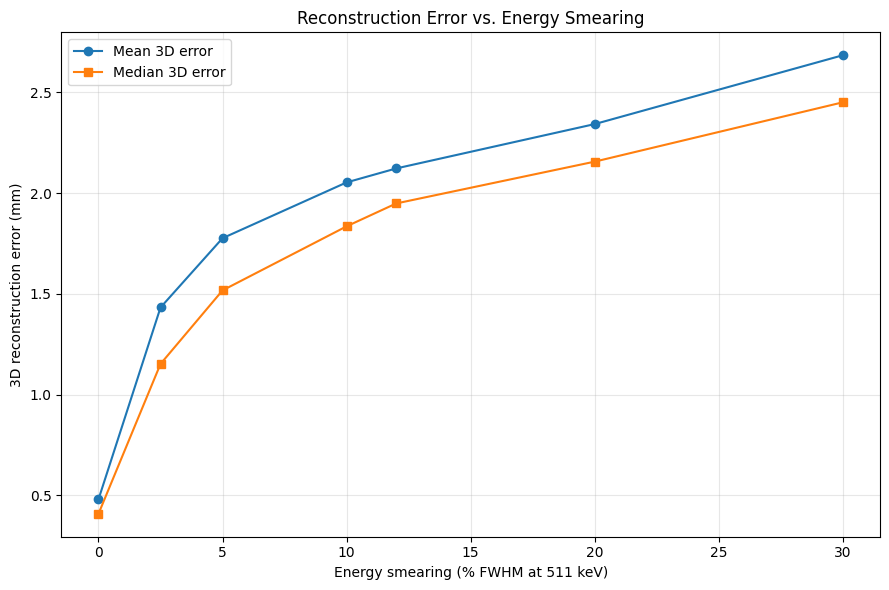

In [54]:
new_data_2_5 = pd.DataFrame([
    {
        "smearing_pct": pct,
        "mean_3d_error": mean_error_2_5,
        "median_3d_error": median_error_2_5,
        "x_mae": x_mae_2_5,
        "y_mae": y_mae_2_5,
        "z_mae": z_mae_2_5,
        "x_r2": x_r2_2_5,
        "y_r2": y_r2_2_5,
        "z_r2": z_r2_2_5
    }
])

# Concatenate with the existing energy_df and sort
combined_df = pd.concat([energy_df, new_data_2_5], ignore_index=True)
combined_df = combined_df.sort_values(by="smearing_pct").reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.plot(combined_df["smearing_pct"], combined_df["mean_3d_error"], marker="o", label="Mean 3D error")
plt.plot(combined_df["smearing_pct"], combined_df["median_3d_error"], marker="s", label="Median 3D error")
plt.xlabel("Energy smearing (% FWHM at 511 keV)")
plt.ylabel("3D reconstruction error (mm)")
plt.title("Reconstruction Error vs. Energy Smearing")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
print("Per-smearing-level metrics:")
for index, row in combined_df.iterrows():
    print(f"  {int(row['smearing_pct'])}% smearing: Mean 3D error = {row['mean_3d_error']:.3f} mm, Median 3D error = {row['median_3d_error']:.3f} mm")
    print(f"    X: MAE = {row['x_mae']:.3f} mm, R² = {row['x_r2']:.3f}")
    print(f"    Y: MAE = {row['y_mae']:.3f} mm, R² = {row['y_r2']:.3f}")
    print(f"    Z: MAE = {row['z_mae']:.3f} mm, R² = {row['z_r2']:.3f}")
    print(f" Overall R² = { (row['x_r2'] + row['y_r2'] + row['z_r2']) / 3:.3f}")

Per-smearing-level metrics:
  0% smearing: Mean 3D error = 0.480 mm, Median 3D error = 0.408 mm
    X: MAE = 0.249 mm, R² = 0.967
    Y: MAE = 0.241 mm, R² = 0.979
    Z: MAE = 0.233 mm, R² = 0.969
 Overall R² = 0.972
  2% smearing: Mean 3D error = 1.432 mm, Median 3D error = 1.152 mm
    X: MAE = 0.738 mm, R² = 0.723
    Y: MAE = 0.702 mm, R² = 0.833
    Z: MAE = 0.714 mm, R² = 0.707
 Overall R² = 0.754
  5% smearing: Mean 3D error = 1.776 mm, Median 3D error = 1.517 mm
    X: MAE = 0.898 mm, R² = 0.631
    Y: MAE = 0.888 mm, R² = 0.751
    Z: MAE = 0.888 mm, R² = 0.578
 Overall R² = 0.653
  10% smearing: Mean 3D error = 2.053 mm, Median 3D error = 1.835 mm
    X: MAE = 1.036 mm, R² = 0.525
    Y: MAE = 1.050 mm, R² = 0.671
    Z: MAE = 1.010 mm, R² = 0.471
 Overall R² = 0.556
  12% smearing: Mean 3D error = 2.122 mm, Median 3D error = 1.948 mm
    X: MAE = 1.064 mm, R² = 0.500
    Y: MAE = 1.083 mm, R² = 0.670
    Z: MAE = 1.049 mm, R² = 0.458
 Overall R² = 0.543
  20% smearing: Mean